# Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

1. Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. 

1. Would you accept that coupon and take a short detour to the restaurant? 

1. Would you accept the coupon but use it on a subsequent trip? 

1. Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? 

1. What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? 

1. What about if it was just you and your partner in the car? 
    
1. Would weather impact the rate of acceptance? What about the time of day?

1. Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not,

    * but what are the factors that determine whether a driver accepts the coupon once it is delivered to them?

1.. How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. 
The survey describes different driving scenarios including the 
1. destination,
2. current time,
3. weather,
4. passenger, etc.,


1. and then ask the person whether he will accept the coupon if he is the driver.
2. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’
3. and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.

1. There are five different types of coupons --
   1. less expensive restaurants (under \$20),
   2. coffee houses,
   3. carry out & take away,
   4. bar, and
   5. more expensive restaurants (\$20 - $50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  

To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. 

You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from plotly import express as px

### Problems

Use the prompts below to get started with your data analysis.  

1. Read in the `coupons.csv` file.




In [3]:
data = pd.read_csv('data/coupons.csv')

In [4]:
data.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


2. Investigate the dataset for missing or problematic data.

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12684 entries, 0 to 12683
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   destination           12684 non-null  object
 1   passanger             12684 non-null  object
 2   weather               12684 non-null  object
 3   temperature           12684 non-null  int64 
 4   time                  12684 non-null  object
 5   coupon                12684 non-null  object
 6   expiration            12684 non-null  object
 7   gender                12684 non-null  object
 8   age                   12684 non-null  object
 9   maritalStatus         12684 non-null  object
 10  has_children          12684 non-null  int64 
 11  education             12684 non-null  object
 12  occupation            12684 non-null  object
 13  income                12684 non-null  object
 14  car                   108 non-null    object
 15  Bar                   12577 non-null

In [6]:
data.shape

(12684, 26)

In [7]:
data.isna().sum()

destination                 0
passanger                   0
weather                     0
temperature                 0
time                        0
coupon                      0
expiration                  0
gender                      0
age                         0
maritalStatus               0
has_children                0
education                   0
occupation                  0
income                      0
car                     12576
Bar                       107
CoffeeHouse               217
CarryAway                 151
RestaurantLessThan20      130
Restaurant20To50          189
toCoupon_GEQ5min            0
toCoupon_GEQ15min           0
toCoupon_GEQ25min           0
direction_same              0
direction_opp               0
Y                           0
dtype: int64

3. Decide what to do about your missing data -- drop, replace, other...

### Car

In [8]:
data['car'].unique()

array([nan, 'Scooter and motorcycle', 'crossover', 'Mazda5',
       'do not drive', 'Car that is too old to install Onstar :D'],
      dtype=object)

In [9]:
data['car'][data['car'].isna()]

0        NaN
1        NaN
2        NaN
3        NaN
4        NaN
        ... 
12679    NaN
12680    NaN
12681    NaN
12682    NaN
12683    NaN
Name: car, Length: 12576, dtype: object

In [10]:
data['car'] = data['car'].fillna('')

### Bar

In [11]:
data['Bar'].unique()

array(['never', 'less1', '1~3', 'gt8', nan, '4~8'], dtype=object)

In [12]:
data['Bar'] = data['Bar'].fillna('')

In [13]:
data['CoffeeHouse'].unique()

array(['never', 'less1', '4~8', '1~3', 'gt8', nan], dtype=object)

In [14]:
data['CoffeeHouse'] = data['CoffeeHouse'].fillna('')

In [15]:
data['CarryAway'].unique()

array([nan, '4~8', '1~3', 'gt8', 'less1', 'never'], dtype=object)

In [16]:
data['CarryAway'] = data['CarryAway'].fillna('')

In [17]:
data['RestaurantLessThan20'].unique()

array(['4~8', '1~3', 'less1', 'gt8', nan, 'never'], dtype=object)

In [18]:
data['RestaurantLessThan20'] = data['RestaurantLessThan20'].fillna('')

In [19]:
data['Restaurant20To50'].unique()

array(['1~3', 'less1', 'never', 'gt8', '4~8', nan], dtype=object)

In [20]:
data['Restaurant20To50'] = data['Restaurant20To50'].fillna('')

In [21]:
data.isna().sum()

destination             0
passanger               0
weather                 0
temperature             0
time                    0
coupon                  0
expiration              0
gender                  0
age                     0
maritalStatus           0
has_children            0
education               0
occupation              0
income                  0
car                     0
Bar                     0
CoffeeHouse             0
CarryAway               0
RestaurantLessThan20    0
Restaurant20To50        0
toCoupon_GEQ5min        0
toCoupon_GEQ15min       0
toCoupon_GEQ25min       0
direction_same          0
direction_opp           0
Y                       0
dtype: int64

In [22]:
data.eq('').sum()

destination                 0
passanger                   0
weather                     0
temperature                 0
time                        0
coupon                      0
expiration                  0
gender                      0
age                         0
maritalStatus               0
has_children                0
education                   0
occupation                  0
income                      0
car                     12576
Bar                       107
CoffeeHouse               217
CarryAway                 151
RestaurantLessThan20      130
Restaurant20To50          189
toCoupon_GEQ5min            0
toCoupon_GEQ15min           0
toCoupon_GEQ25min           0
direction_same              0
direction_opp               0
Y                           0
dtype: int64

This is identical to the isna.sum() statent above, so all values have a value or they were Nan and have been set to ''

In [23]:
data.shape

(12684, 26)

In [24]:
len(data[data.duplicated() == True])

74

74 of the 12684 rows are duplicates. Its unclear if these are problems with the data or if the two individual of the same profile simply used the coupons are the same time. Given the time is a rough measure of time.. no minutes or seconds is it possible that two single females 21 years old used the coupons at the same time.

Use both duplicate and dropped duplicaate to see if there is any difference

In [25]:
data_deduped = data.drop_duplicates()

In [26]:
data.columns

Index(['destination', 'passanger', 'weather', 'temperature', 'time', 'coupon',
       'expiration', 'gender', 'age', 'maritalStatus', 'has_children',
       'education', 'occupation', 'income', 'car', 'Bar', 'CoffeeHouse',
       'CarryAway', 'RestaurantLessThan20', 'Restaurant20To50',
       'toCoupon_GEQ5min', 'toCoupon_GEQ15min', 'toCoupon_GEQ25min',
       'direction_same', 'direction_opp', 'Y'],
      dtype='object')

In [27]:
data['time'].unique()

array(['2PM', '10AM', '6PM', '7AM', '10PM'], dtype=object)

In [28]:
data.loc[0]

destination                      No Urgent Place
passanger                                  Alone
weather                                    Sunny
temperature                                   55
time                                         2PM
coupon                           Restaurant(<20)
expiration                                    1d
gender                                    Female
age                                           21
maritalStatus                  Unmarried partner
has_children                                   1
education               Some college - no degree
occupation                            Unemployed
income                           $37500 - $49999
car                                             
Bar                                        never
CoffeeHouse                                never
CarryAway                                       
RestaurantLessThan20                         4~8
Restaurant20To50                             1~3
toCoupon_GEQ5min    

In [29]:
data.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,,4~8,1~3,1,1,0,0,1,0


4. What proportion of the total observations chose to accept the coupon?



In [30]:
data['Y'].unique()

array([1, 0])

In [31]:
len(data[data['Y'] == 1])/ len(data) * 100

56.84326710816777

5. Use a bar plot to visualize the `coupon` column.

([0, 1, 2, 3, 4],
 [Text(0, 0, 'Restaurant(<20)'),
  Text(1, 0, 'Coffee House'),
  Text(2, 0, 'Carry out & Take away'),
  Text(3, 0, 'Bar'),
  Text(4, 0, 'Restaurant(20-50)')])

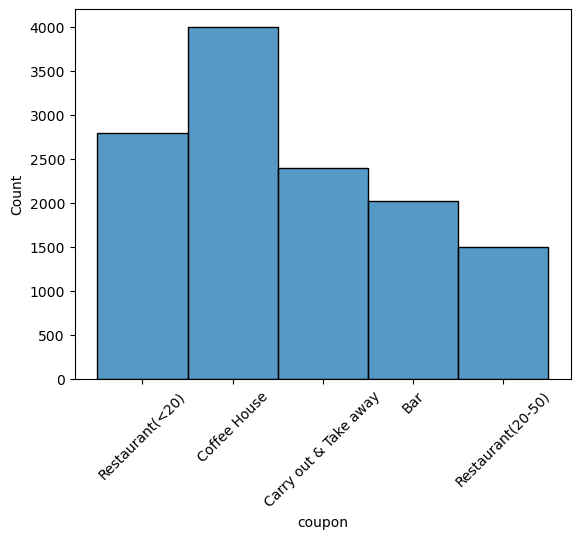

In [32]:
sns.histplot(data=data,x='coupon')
plt.xticks(rotation=45)

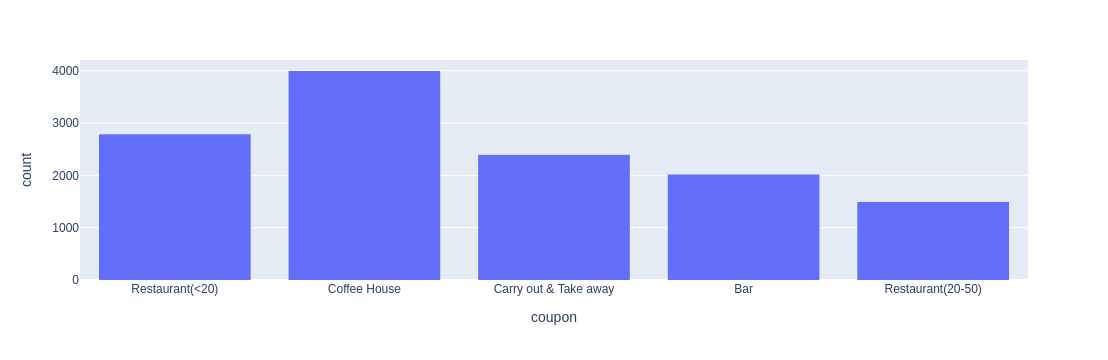

In [37]:
fig = px.histogram(data, x="coupon")                
fig.show()

6. Use a histogram to visualize the temperature column.

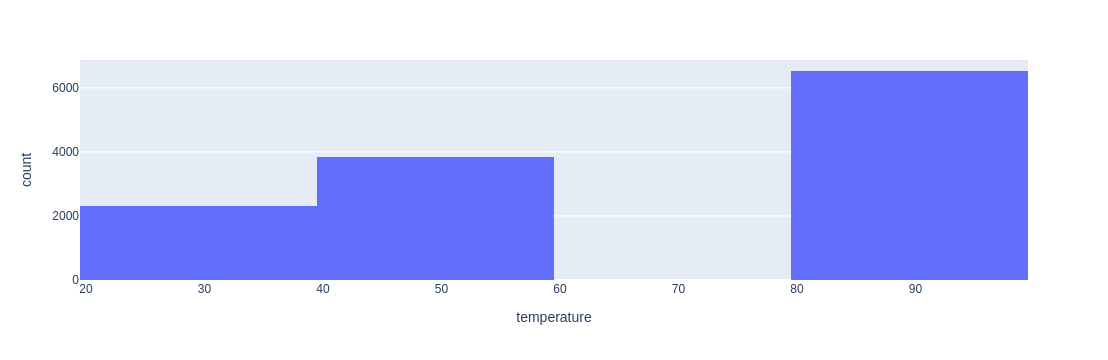

In [38]:
fig = px.histogram(data, x="temperature")                
fig.show()

(array([20., 30., 40., 50., 60., 70., 80., 90.]),
 [Text(20.0, 0, '20'),
  Text(30.0, 0, '30'),
  Text(40.0, 0, '40'),
  Text(50.0, 0, '50'),
  Text(60.0, 0, '60'),
  Text(70.0, 0, '70'),
  Text(80.0, 0, '80'),
  Text(90.0, 0, '90')])

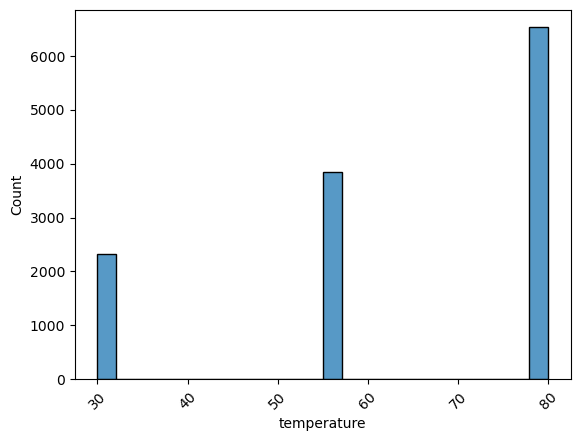

In [39]:
sns.histplot(data=data,x='temperature')
plt.xticks(rotation=45)

In [50]:
data['coupon'].unique()

array(['Restaurant(<20)', 'Coffee House', 'Carry out & Take away', 'Bar',
       'Restaurant(20-50)'], dtype=object)

**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.


In [49]:
bardf = data[['Bar']]

2. What proportion of bar coupons were accepted?


In [ ]:
len(data[data['coupon'] == ''])

In [ ]:
coupon_len = len(data['coupon'])

In [ ]:
yes_len = len(data[data['Y'] == 1])

In [ ]:
yes_len/coupon_len

3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


In [ ]:
data.columns

In [53]:
data['Y'].unique()

array([1, 0])

In [52]:
data['Bar'].unique()

array(['never', 'less1', '1~3', 'gt8', '', '4~8'], dtype=object)

In [54]:
data['Bar'] == 'less1'

0        False
1        False
2        False
3        False
4        False
         ...  
12679    False
12680    False
12681    False
12682    False
12683    False
Name: Bar, Length: 12684, dtype: bool

In [55]:
yes_coupon = data[data['Y'] == 1]

In [56]:
ylte3 = len(yes_coupon[(yes_coupon['Bar'] == 'less1') | (yes_coupon['Bar'] == '1~3')])
ylte3

3501

In [57]:
yg3 = len(yes_coupon[ (yes_coupon['Bar'] == '4~8') | (yes_coupon['Bar'] == 'gt8')])
yg3

887

In [58]:
ylte3 / yg3

3.947012401352875

In [59]:
lte3 = len(data[(data['Bar'] == 'less1') | (data['Bar'] == '1~3')])
lte3

5955

In [60]:
dfle3 = data[(data['Bar'] == 'less1') | (data['Bar'] == '1~3')]

In [61]:
dfle3['Y'] = dfle3['Y'].astype(int)

/tmp/ipykernel_8639/3039566815.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [62]:
dfle3['Y'] == 0

66       False
67       False
68       False
69       False
70       False
         ...  
12657     True
12658    False
12659     True
12660     True
12661     True
Name: Y, Length: 5955, dtype: bool

In [63]:
len(dfle3)

5955

(array([-0.2,  0. ,  0.2,  0.4,  0.6,  0.8,  1. ,  1.2]),
 [Text(-0.2, 0, '−0.2'),
  Text(0.0, 0, '0.0'),
  Text(0.2, 0, '0.2'),
  Text(0.4000000000000001, 0, '0.4'),
  Text(0.6000000000000001, 0, '0.6'),
  Text(0.8, 0, '0.8'),
  Text(1.0000000000000002, 0, '1.0'),
  Text(1.2000000000000002, 0, '1.2')])

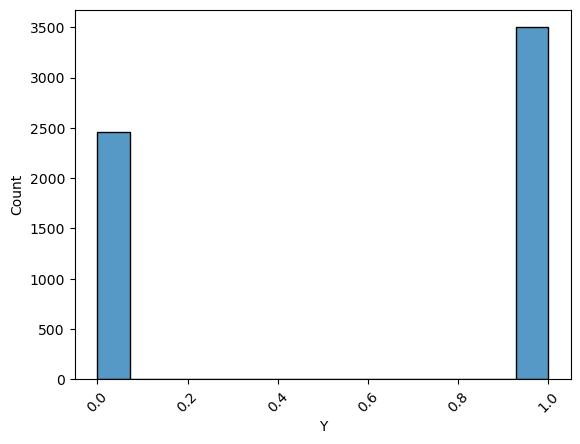

In [64]:
sns.histplot(data=dfle3,x='Y')
plt.xticks(rotation=45)

In [65]:
fig = px.histogram(dfle3, x="Y")                
fig.show()


In [66]:
dfg3 = data[ (data['Bar'] == '4~8') | (data['Bar'] == 'gt8')]
print(len(dfg3))

1425


In [67]:
dfg3['Y'] = dfg3['Y'].astype(int)

/tmp/ipykernel_8639/1239302976.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [68]:
fig = px.histogram(dfg3, x="Y")                
fig.show()

In [69]:
len(dfle3[dfle3['Y'] == 1]) # <= 3 times a month yes

3501

In [70]:
len(dfg3[dfg3['Y'] == 1]) # > 3 times a month yes

887

In [71]:
len(dfle3[dfle3['Y'] == 0])

2454

In [72]:
len(dfg3[dfg3['Y'] == 0])

538

In [73]:
3501 + 2454

5955

In [74]:
887 + 538

1425

Those who went to the bar three or less times a month used the coupon nearly four times more than those who went to the bar greater than three times a month. Those who went to the bar three or less times a month were 3501. Those more than three were 887. The ration is 3501/887 == 947012401352875

4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?


In [75]:
fig = px.histogram(data, x="age")                
fig.show()

In [76]:
morethan_1_month = data[ (data['Bar'] == '1~3') | (data['Bar'] == '4~8') | (data['Bar'] == 'gt8')]
morethan_1_month .head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
88,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Male,21,Single,...,less1,1~3,less1,1~3,1,0,0,0,1,0
89,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Male,21,Single,...,less1,1~3,less1,1~3,1,0,0,0,1,1
90,No Urgent Place,Friend(s),Sunny,80,10AM,Bar,1d,Male,21,Single,...,less1,1~3,less1,1~3,1,0,0,0,1,1
91,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Male,21,Single,...,less1,1~3,less1,1~3,1,1,0,0,1,1
92,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Male,21,Single,...,less1,1~3,less1,1~3,1,0,0,0,1,1


In [77]:
morethan_1_month['age'].unique()

array(['21', '26', '31', '50plus', '41', '36', '46', 'below21'],
      dtype=object)

In [78]:
g1m_g25 = morethan_1_month[(morethan_1_month['age'] != '21') & (morethan_1_month['age'] != 'below21')]
g1m_g25['age'].unique()

array(['26', '31', '50plus', '41', '36', '46'], dtype=object)

In [79]:
len(g1m_g25)

2777

In [80]:
g1m_g25['Y'] = g1m_g25['Y'].astype(int)

/tmp/ipykernel_8639/4137488735.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [81]:
fig = px.histogram(g1m_g25, x="Y")                
fig.show()

In [82]:
g1m_lt25 = morethan_1_month[(morethan_1_month['age'] == '21') | (morethan_1_month['age'] == 'below21')]
g1m_lt25['age'].unique()

array(['21', 'below21'], dtype=object)

In [83]:
len(g1m_lt25)

1121

In [84]:
g1m_lt25['Y'] = g1m_lt25['Y'].astype(int)

/tmp/ipykernel_8639/3891138561.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [85]:
fig = px.histogram(g1m_lt25, x="Y")                
fig.show()

5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.


In [86]:
morethan_1_month = data[ (data['Bar'] == '1~3') | (data['Bar'] == '4~8') | (data['Bar'] == 'gt8')]
morethan_1_month['Bar'].unique()

array(['1~3', 'gt8', '4~8'], dtype=object)

In [87]:
g1m_nk = morethan_1_month[morethan_1_month['has_children'] == 0]
g1m_nk.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
88,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Male,21,Single,...,less1,1~3,less1,1~3,1,0,0,0,1,0
89,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Male,21,Single,...,less1,1~3,less1,1~3,1,0,0,0,1,1
90,No Urgent Place,Friend(s),Sunny,80,10AM,Bar,1d,Male,21,Single,...,less1,1~3,less1,1~3,1,0,0,0,1,1
91,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Male,21,Single,...,less1,1~3,less1,1~3,1,1,0,0,1,1
92,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Male,21,Single,...,less1,1~3,less1,1~3,1,0,0,0,1,1


In [88]:
data["occupation"].unique()

array(['Unemployed', 'Architecture & Engineering', 'Student',
       'Education&Training&Library', 'Healthcare Support',
       'Healthcare Practitioners & Technical', 'Sales & Related',
       'Management', 'Arts Design Entertainment Sports & Media',
       'Computer & Mathematical', 'Life Physical Social Science',
       'Personal Care & Service', 'Community & Social Services',
       'Office & Administrative Support', 'Construction & Extraction',
       'Legal', 'Retired', 'Installation Maintenance & Repair',
       'Transportation & Material Moving', 'Business & Financial',
       'Protective Service', 'Food Preparation & Serving Related',
       'Production Occupations',
       'Building & Grounds Cleaning & Maintenance',
       'Farming Fishing & Forestry'], dtype=object)

In [89]:
g1m_nk["occupation"].unique()

array(['Student', 'Healthcare Support', 'Management', 'Unemployed',
       'Sales & Related', 'Office & Administrative Support',
       'Construction & Extraction', 'Legal',
       'Life Physical Social Science',
       'Healthcare Practitioners & Technical',
       'Architecture & Engineering', 'Protective Service',
       'Arts Design Entertainment Sports & Media',
       'Computer & Mathematical', 'Food Preparation & Serving Related',
       'Education&Training&Library', 'Community & Social Services',
       'Production Occupations', 'Business & Financial',
       'Transportation & Material Moving'], dtype=object)

In [90]:
flm_nk_nfff = g1m_nk[g1m_nk['occupation'] != 'Farming Fishing & Forestry']

In [91]:
flm_nk_nfff["occupation"].unique()

array(['Student', 'Healthcare Support', 'Management', 'Unemployed',
       'Sales & Related', 'Office & Administrative Support',
       'Construction & Extraction', 'Legal',
       'Life Physical Social Science',
       'Healthcare Practitioners & Technical',
       'Architecture & Engineering', 'Protective Service',
       'Arts Design Entertainment Sports & Media',
       'Computer & Mathematical', 'Food Preparation & Serving Related',
       'Education&Training&Library', 'Community & Social Services',
       'Production Occupations', 'Business & Financial',
       'Transportation & Material Moving'], dtype=object)

In [92]:
fig = px.histogram(flm_nk_nfff, x="Y")                
fig.show()

In [93]:
flm_nk_nfff.describe()

,temperature,has_children,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
count,2787.000000,2787.0,2787.0,2787.000000,2787.000000,2787.000000,2787.000000,2787.000000
mean,62.956584,0.0,1.0,0.523861,0.119125,0.220309,0.779691,0.617151
std,19.336516,0.0,0.0,0.499520,0.323993,0.414529,0.414529,0.486169
min,30.000000,0.0,1.0,0.000000,0.000000,0.000000,0.000000,0.000000
25%,55.000000,0.0,1.0,0.000000,0.000000,0.000000,1.000000,0.000000
50%,80.000000,0.0,1.0,1.000000,0.000000,0.000000,1.000000,1.000000
75%,80.000000,0.0,1.0,1.000000,0.000000,0.000000,1.000000,1.000000
max,80.000000,0.0,1.0,1.000000,1.000000,1.000000,1.000000,1.000000


6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



In [94]:
flm_nk_nfff.Bar.unique()

array(['1~3', 'gt8', '4~8'], dtype=object)

In [95]:
flm_nk_nfff.columns

Index(['destination', 'passanger', 'weather', 'temperature', 'time', 'coupon',
       'expiration', 'gender', 'age', 'maritalStatus', 'has_children',
       'education', 'occupation', 'income', 'car', 'Bar', 'CoffeeHouse',
       'CarryAway', 'RestaurantLessThan20', 'Restaurant20To50',
       'toCoupon_GEQ5min', 'toCoupon_GEQ15min', 'toCoupon_GEQ25min',
       'direction_same', 'direction_opp', 'Y'],
      dtype='object')

In [96]:
data.maritalStatus.unique()

array(['Unmarried partner', 'Single', 'Married partner', 'Divorced',
       'Widowed'], dtype=object)

In [97]:
morethan_1_month = data[ (data['Bar'] == '1~3') | (data['Bar'] == '4~8') | (data['Bar'] == 'gt8')]
morethan_1_month['Bar'].unique()

array(['1~3', 'gt8', '4~8'], dtype=object)

In [98]:
g1m_nk= morethan_1_month[morethan_1_month['passanger'] != 'Kid(s)']
glmk_nk_nd = g1m_nk[g1m_nk['maritalStatus'] == 'Divorced']


In [99]:
glmk_nk_nd['Y'] = glmk_nk_nd['Y'].astype(int)

/tmp/ipykernel_8639/1326040933.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [100]:
fig = px.histogram(glmk_nk_nd, x="Y")                
fig.show()

In [101]:
morethan_1_month = data[ (data['Bar'] == '1~3') | (data['Bar'] == '4~8') | (data['Bar'] == 'gt8')]
morethan_1_month['age'].unique()

array(['21', '26', '31', '50plus', '41', '36', '46', 'below21'],
      dtype=object)

In [102]:
m1m_lt30 = morethan_1_month[morethan_1_month['age'].isin(["21", "below21"])]
m1m_lt30['Y'] = m1m_lt30['Y'].astype(int)

/tmp/ipykernel_8639/968767669.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [103]:
fig = px.histogram(m1m_lt30, x="Y")                
fig.show()

In [104]:
#go to cheap restaurants more than 4 times a month and income is less than 50K.

In [105]:
data.columns

Index(['destination', 'passanger', 'weather', 'temperature', 'time', 'coupon',
       'expiration', 'gender', 'age', 'maritalStatus', 'has_children',
       'education', 'occupation', 'income', 'car', 'Bar', 'CoffeeHouse',
       'CarryAway', 'RestaurantLessThan20', 'Restaurant20To50',
       'toCoupon_GEQ5min', 'toCoupon_GEQ15min', 'toCoupon_GEQ25min',
       'direction_same', 'direction_opp', 'Y'],
      dtype='object')

In [106]:
crg4 = data[data['RestaurantLessThan20'].isin(["4~8","gt8"])]
crg4["income"].unique()

array(['$37500 - $49999', '$62500 - $74999', '$100000 or More',
       '$50000 - $62499', '$25000 - $37499', '$75000 - $87499',
       '$87500 - $99999', '$12500 - $24999', 'Less than $12500'],
      dtype=object)

In [107]:
crg4_il50K = crg4[crg4["income"].isin(["$37500 - $49999","$25000 - $37499"])]

In [108]:
crg4_il50K['Y'] = crg4_il50K['Y'].astype(int)

/tmp/ipykernel_8639/1045735834.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



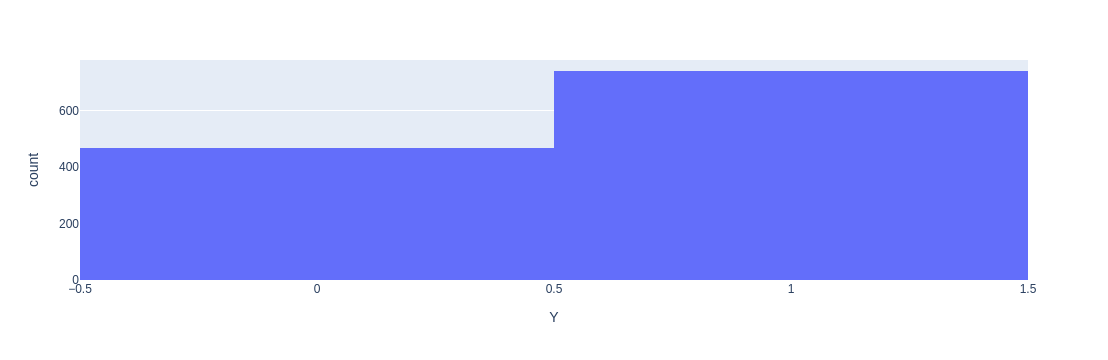

In [109]:
fig = px.histogram(crg4_il50K, x="Y")                
fig.show()

7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  